Reproducing results of the CTMC framework for a single household using the SSA with households uncoupled

In [12]:
module female_SSA
    include("SSA_fem_coupled_invasion.jl")
end

module ME_coupled
    include("ME_disperser_pool.jl")
end

Main.ME_coupled

In [13]:
# Define parameters dictionary
w0 = 5
m0 = 5
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
rho = 0.5  # rate visit the households
tau = 0.5  # rate leave the households
phi = 0.85 # wolbachia fitness effect on birth rate

K = 30 
d = 12/100
k = 0.3
h = 0.19*100^k
b = 0.54
H = 100
u = 1
v = 1

t_start = 0
t_end = 5000   # start time and end time (days) of simulation

states = ME_coupled.state_space(K)
n_states = length(states)

num_simulations = 1000

parameters_fem = Dict(           # dictionary of parameters
    :m0 => m0,
    :w0 => w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :n_states => n_states,
    :seed => 1234
)

Dict{Symbol, Real} with 19 entries:
  :b        => 0.54
  :m_free0  => 0
  :rho      => 0.5
  :t_start  => 0
  :h        => 0.756404
  :m0       => 5
  :w0       => 5
  :K        => 30
  :n_states => 496
  :phi      => 0.85
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :tau      => 0.5
  :t_end    => 5000
  :H        => 100
  :w_free0  => 0
  :seed     => 1234

In [14]:
# Add worker processes
using Distributed

# remove any workers hanging around e.g. after code crashes
if length(workers()) > 1
    rmprocs(workers())
end

addprocs(6)  # Adjust the number based on your system's cores

@everywhere using SharedArrays   # Load the SharedArrays package on all worker processes

# Define your module with the function to be run in parallel
@everywhere module Wolbachia_coupled_para
    include("SSA_Wolb_coupled_hhold_dist.jl")#("SSA_fem_coupled_invasion.jl")  
end

# Define SharedArrays to store the results
#m_results = SharedArray{Float64}(result_length, num_simulations)
#w_results = SharedArray{Float64}(result_length, num_simulations)

#free_m_results = SharedArray{Float64}(result_length, num_simulations)
#free_w_results = SharedArray{Float64}(result_length, num_simulations)

# can't store results for household distributions as shared arrays
#num_house_results = SharedArray{Int64}(result_length*(n_states+1), num_simulations)
#key_house_results = SharedArray{Tuple{Int, Int}}(result_length*(n_states+1), num_simulations)

inv_results = SharedArray{Float64}(num_simulations)
inv_time_results = SharedArray{Float64}(num_simulations)

# Run the simulations in parallel; @time just times the whole block, @sync ensures all 
# processes are done before moving on
@time begin
    @sync @distributed for i in 1:num_simulations
        println("Starting simulation $i of $num_simulations")
        m_vec, w_vec = Wolbachia_coupled_para.gillespie(parameters_fem)
        #m_results[:, i] = m_vec
        #w_results[:, i] = w_vec
        #free_m_results[:, i] = free_m_vec
        #free_w_results[:, i] = free_w_vec
        #num_house_results[:, i] = num_house_vec
        #key_house_results[:, i] = key_house_vec
        #inv_results[i] = inv
        #inv_time_results[i] = inv_time
        
        println("Finished simulation $i of $num_simulations")
    end
end

using Statistics

#Mss = mean(m_results, dims=2)
#Wss = mean(w_results, dims=2)

rmprocs(workers())  # Remove the worker processes

      From worker 33:	Starting simulation 168 of 1000
      From worker 34:	Starting simulation 335 of 1000
      From worker 32:	Starting simulation 1 of 1000
      From worker 36:	Starting simulation 669 of 1000
      From worker 37:	Starting simulation 835 of 1000
      From worker 35:	Starting simulation 502 of 1000
      From worker 36:	Finished simulation 669 of 1000
      From worker 36:	Starting simulation 670 of 1000
      From worker 32:	Finished simulation 1 of 1000
      From worker 32:	Starting simulation 2 of 1000
      From worker 35:	Finished simulation 502 of 1000
      From worker 35:	Starting simulation 503 of 1000
      From worker 37:	Finished simulation 835 of 1000
      From worker 37:	Starting simulation 836 of 1000
      From worker 33:	Finished simulation 168 of 1000
      From worker 33:	Starting simulation 169 of 1000
      From worker 34:	Finished simulation 335 of 1000
      From worker 34:	Starting simulation 336 of 1000
      From worker 36:	Finished sim

Task (done) @0x0000017102e0aab0

In [13]:
inv_prob = sum(inv_results)/num_simulations
filtered_inv_time_results = inv_time_results[inv_results .!= 0]
inv_time = mean(filtered_inv_time_results)

println("Invasion probability: $inv_prob")
println("Invasion time: $inv_time")

In [14]:
inv_prob, inv_time   ## need to remove times when invasion doesn't happen

(0.0, NaN)

Reproducing the colour plots

In [8]:
using Distributed
using Statistics
phivec = 0.25:0.05:1
phi_len = length(phivec)
max_w = 10

inv_prob_vec = zeros(phi_len, max_w)
inv_time_vec = zeros(phi_len, max_w)

for i in 1:phi_len
    for j in 1:max_w
        println("Starting phi = $phivec[i] and w0 = $j")
        parameters_fem[:phi] = phivec[i]
        parameters_fem[:w0] = j
        parameters_fem[:m0] = 10 - j

        # Add worker processes

        # remove any workers hanging around e.g. after code crashes
        if length(workers()) > 1
            rmprocs(workers())
        end

        addprocs(6)  # Adjust the number based on your system's cores
        @everywhere using SharedArrays   # Load the SharedArrays package on all worker processes
        # Define your module with the function to be run in parallel
        @everywhere module Wolbachia_coupled_para
            include("SSA_fem_coupled_invasion.jl")  
        end

        inv_results = SharedArray{Float64}(num_simulations)
        inv_time_results = SharedArray{Float64}(num_simulations)

        # Run the simulations in parallel; @time just times the whole block, @sync ensures all 
        # processes are done before moving on
        @time begin
            @sync @distributed for i in 1:num_simulations
                #println("Starting simulation $i of $num_simulations")
                m_vec, w_vec, free_m_vec, free_w_vec, inv, inv_time = Wolbachia_coupled_para.gillespie(parameters_fem)
                inv_results[i] = inv
                inv_time_results[i] = inv_time
                #println("Finished simulation $i of $num_simulations")
            end
        end
        rmprocs(workers())  # Remove the worker processes
        inv_prob_vec[i,j] = sum(inv_results)/num_simulations
        filtered_inv_time_results = inv_time_results[inv_results .!= 0]
        inv_time_vec[i,j] = mean(filtered_inv_time_results)
    end
end

Starting phi = 0.25:0.05:1.0[i] and w0 = 1


1507.824828 seconds (61.26 k allocations: 3.205 MiB, 0.00% compilation time)
Starting phi = 0.25:0.05:1.0[i] and w0 = 2


1412.881729 seconds (34.86 k allocations: 1.316 MiB, 0.07% gc time, 0.02% compilation time)
Starting phi = 0.25:0.05:1.0[i] and w0 = 3


1379.139380 seconds (28.54 k allocations: 1012.328 KiB)
Starting phi = 0.25:0.05:1.0[i] and w0 = 4


1472.656181 seconds (30.40 k allocations: 1.040 MiB)
Starting phi = 0.25:0.05:1.0[i] and w0 = 5


...

 23.511545 seconds (2.79 k allocations: 186.469 KiB)
Starting phi = 0.25:0.05:1.0[i] and w0 = 7


 21.552483 seconds (2.75 k allocations: 180.859 KiB)
Starting phi = 0.25:0.05:1.0[i] and w0 = 8


 18.251255 seconds (2.69 k allocations: 179.969 KiB)
Starting phi = 0.25:0.05:1.0[i] and w0 = 9


 15.964291 seconds (2.63 k allocations: 177.500 KiB)
Starting phi = 0.25:0.05:1.0[i] and w0 = 10


  4.552907 seconds (2.42 k allocations: 171.094 KiB)


In [9]:
using JLD2

@save "inv_probs_pop10_move05.jld2" inv_prob_vec
@save "inv_times_pop10_move05.jld2" inv_time_vec

In [77]:
using JLD2

@load "inv_probs_pop10_move05.jld2" inv_prob_vec
@load "inv_times_pop10_move05.jld2" inv_time_vec

1-element Vector{Symbol}:
 :inv_time_vec

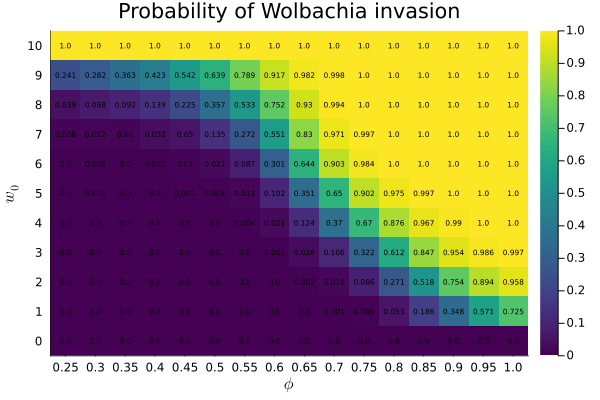

In [10]:
using Plots

phivec = 0.25:0.05:1
phi_len = length(phivec)
max_w = 10
inv_prob_map = zeros(phi_len, max_w)
inv_prob_map[:,:] = inv_prob_vec
inv_prob_map[:,10] .= 1
zeros_col = zeros(size(inv_prob_map, 1),1)
inv_prob_map = hcat(zeros_col, inv_prob_map)

# Create the heatmap
p = heatmap(transpose(inv_prob_map), color=:viridis, xlabel = "\$\\phi\$", ylabel = "\$w_0\$", title = "Probability of Wolbachia invasion",
            xticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,16], 
                        [0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1]), yticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],[0,1, 2, 3, 4, 5, 6, 7, 8, 9, 10]))

# Add the values of inv_prob_vec onto the heatmap squares
for i in 1:size(inv_prob_map, 1)
    for j in 1:size(inv_prob_map, 2)
        annotate!(p, [(i, j, text(string(inv_prob_map[i, j]), 5))])
    end
end

# Display the plot
savefig(p, "heatmap_inv_prob_pops10_move05.pdf")
p

Reproducing colour plots over set of initial household states

In [32]:
using Distributed

parameters_fem[:phi] = 0.85
max_w = 10

inv_prob_vec = zeros(max_w, max_w)
inv_time_vec = zeros(max_w, max_w)

for i in 1:max_w
    for j in 1:max_w
        println("Starting m0 = $i and w0 = $j")
        parameters_fem[:m0] = i
        parameters_fem[:w0] = j
    
        # Add worker processes
        # remove any workers hanging around e.g. after code crashes
        if length(workers()) > 1
            rmprocs(workers())
        end

        addprocs(6)  # Adjust the number based on your system's cores
        @everywhere using SharedArrays   # Load the SharedArrays package on all worker processes
        # Define your module with the function to be run in parallel
        @everywhere module Wolbachia_coupled_para
            include("SSA_fem_coupled_invasion.jl")  
        end

        inv_results = SharedArray{Float64}(num_simulations)
        inv_time_results = SharedArray{Float64}(num_simulations)

        # Run the simulations in parallel; @time just times the whole block, @sync ensures all 
        # processes are done before moving on
        @time begin
            @sync @distributed for i in 1:num_simulations
                #println("Starting simulation $i of $num_simulations")
                m_vec, w_vec, free_m_vec, free_w_vec, inv, inv_time = Wolbachia_coupled_para.gillespie(parameters_fem)
                inv_results[i] = inv
                inv_time_results[i] = inv_time
                #println("Finished simulation $i of $num_simulations")
            end
        end
        rmprocs(workers())  # Remove the worker processes
        inv_prob_vec[i,j] = sum(inv_results)/num_simulations
        filtered_inv_time_results = inv_time_results[inv_results .!= 0]
        inv_time_vec[i,j] = mean(filtered_inv_time_results)
    end
end

In [33]:
using JLD2

@save "inv_probs_states.jld2" inv_prob_vec
@save "inv_times_states.jld2" inv_time_vec

In [10]:
using JLD2
@load "inv_probs_states.jld2" inv_prob_vec
@load "inv_times_states.jld2" inv_time_vec

1-element Vector{Symbol}:
 :inv_time_vec

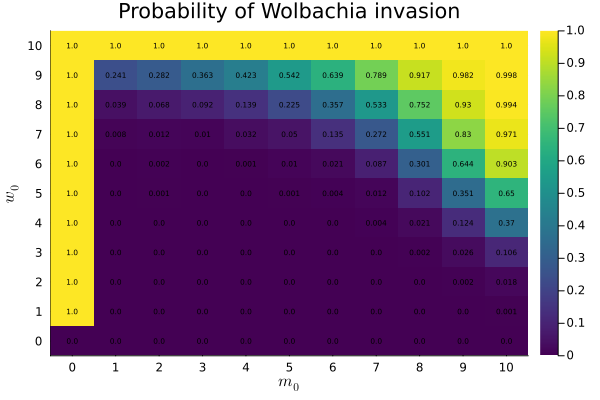

In [11]:
inv_prob_states = zeros(max_w, max_w)
inv_prob_states[:,:] = inv_prob_vec[1:max_w,:]
zeros_row = ones(1,size(inv_prob_states, 1))
inv_prob_states = vcat(zeros_row, inv_prob_states)
zeros_col = zeros(size(inv_prob_states, 1),1)
inv_prob_states = hcat(zeros_col, inv_prob_states)

p=heatmap(transpose(inv_prob_states), color=:viridis, xlabel = "\$m_0\$", ylabel = "\$w_0\$", title = "Probability of Wolbachia invasion", 
            xticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [0,1, 2, 3, 4, 5, 6, 7, 8, 9, 10]), 
            yticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [0,1, 2, 3, 4, 5, 6, 7, 8, 9, 10]))
for i in 1:size(inv_prob_states, 1)
    for j in 1:size(inv_prob_states, 2)
        annotate!(p, [(i, j, text(string(inv_prob_states[i, j]), 5))])
    end
end
savefig(p, "heatmap_inv_prob_states_pops.pdf")
p

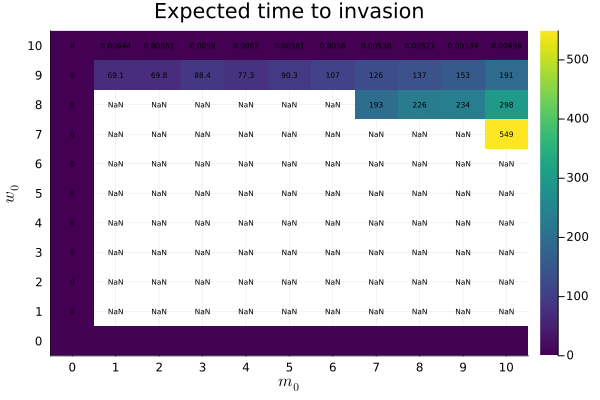

In [81]:
using Plots
max_w = 10

inv_time_states = zeros(max_w, max_w)
inv_time_states[:,:] = inv_time_vec[1:max_w,:]
zeros_row = zeros(1,size(inv_time_states, 1))
inv_time_states = vcat(zeros_row, inv_time_states)
zeros_col = ones(size(inv_time_states, 1),1)
inv_time_states = hcat(zeros_col, inv_time_states)

using Printf

p = heatmap(transpose(inv_time_states), color=:viridis, xlabel = "\$m_0\$", ylabel = "\$w_0\$", title = "Expected time to invasion", xticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [0,1, 2, 3, 4, 5, 6, 7, 8, 9, 10]), 
yticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [0,1, 2, 3, 4, 5, 6, 7, 8, 9, 10]))

for i in 1:size(inv_time_states, 1)
    for j in 2:size(inv_time_states, 2)
        annotate!(p, [(i, j, text(@sprintf("%.3g", inv_time_states[i, j]), 5))])
    end
end

savefig(p, "heatmap_inv_time_states_pops.pdf")
p

Probabilities of reaching specific states

Reproducing results on expected time until Wolbachia extinction

In [30]:
# Define parameters dictionary
w0 = 10
m0 = 0
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
rho = 0  # rate visit the households
tau = 0  # rate leave the households
phi = 0.85 # wolbachia fitness effect on birth rate

K = 30 
d = 12/100
k = 0.3
h = 0.19*100^k
b = 0.54
H = 1
u = 1
v = 1

t_start = 0
t_end = 5000   # start time and end time (days) of simulation

states = ME_coupled.state_space(K)
n_states = length(states)

parameters_fem = Dict(           # dictionary of parameters
    :m0 => m0,
    :w0 => w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :n_states => n_states,
    :seed => 1234
)

Dict{Symbol, Real} with 19 entries:
  :b        => 0.54
  :m_free0  => 0
  :rho      => 0
  :t_start  => 0
  :h        => 0.756404
  :m0       => 0
  :w0       => 10
  :K        => 30
  :n_states => 496
  :phi      => 0.85
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :tau      => 0
  :t_end    => 5000
  :H        => 1
  :w_free0  => 0
  :seed     => 1234

In [31]:
# Run the code in parallel
num_simulations = 10000
# Determine the length of the array returned by gillespie()
result_length = length(t_start:t_end)

parameter_array_fem = [deepcopy(parameters_fem) for _ in 1:num_simulations];
for i in 1:num_simulations
    parameter_array_fem[i][:seed] = i
end

In [32]:
# Add worker processes
using Distributed

# remove any workers hanging around e.g. after code crashes
if length(workers()) > 1
    rmprocs(workers())
end

addprocs(6)  # Adjust the number based on your system's cores

@everywhere using SharedArrays   # Load the SharedArrays package on all worker processes

# Define your module with the function to be run in parallel
@everywhere module Wolbachia_coupled_para
    include("SSA_fem_coupled_invasion.jl")  
end

# Define SharedArrays to store the results
m_results = SharedArray{Float64}(result_length, num_simulations)
w_results = SharedArray{Float64}(result_length, num_simulations)

free_m_results = SharedArray{Float64}(result_length, num_simulations)
free_w_results = SharedArray{Float64}(result_length, num_simulations)

# can't store results for household distributions as shared arrays
#num_house_results = SharedArray{Int64}(result_length*(n_states+1), num_simulations)
#key_house_results = SharedArray{Tuple{Int, Int}}(result_length*(n_states+1), num_simulations)

inv_results = SharedArray{Float64}(num_simulations)
inv_time_results = SharedArray{Float64}(num_simulations)

# Run the simulations in parallel; @time just times the whole block, @sync ensures all 
# processes are done before moving on
@time begin
    @sync @distributed for i in 1:num_simulations
        println("Starting simulation $i of $num_simulations")
        m_vec, w_vec, free_m_vec, free_w_vec, inv, inv_time = Wolbachia_coupled_para.gillespie(parameter_array_fem[i])
        m_results[:, i] = m_vec
        w_results[:, i] = w_vec
        free_m_results[:, i] = free_m_vec
        free_w_results[:, i] = free_w_vec
        #num_house_results[:, i] = num_house_vec
        #key_house_results[:, i] = key_house_vec
        inv_results[i] = inv
        inv_time_results[i] = inv_time
        
        println("Finished simulation $i of $num_simulations")
    end
end

using Statistics

Mss = mean(m_results, dims=2)
Wss = mean(w_results, dims=2)

rmprocs(workers())  # Remove the worker processes

Task (done) @0x0000020bc546a8c0

In [33]:
extinction = sum(inv_results)/num_simulations
ext_time = mean(inv_time_results)

println("Extinction probability: $extinction")
println("Extinction time: $ext_time")

extinction, ext_time

(1.0, 179.37869225727152)

Reproducing results on reversion probability and expected time to reversion

In [42]:
# Define parameters dictionary
w0 = 10
m0 = 0
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
rho = 0  # rate visit the households
tau = 0  # rate leave the households
phi = 0.85 # wolbachia fitness effect on birth rate

K = 30 
d = 12/100
k = 0.3
h = 0.19*100^k
b = 0.54
H = 1
u = 1
v = 0.9

t_start = 0
t_end = 5000   # start time and end time (days) of simulation

states = ME_coupled.state_space(K)
n_states = length(states)

parameters_fem = Dict(           # dictionary of parameters
    :m0 => m0,
    :w0 => w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :n_states => n_states,
    :seed => 1234
)

Dict{Symbol, Real} with 19 entries:
  :b        => 0.54
  :m_free0  => 0
  :rho      => 0
  :t_start  => 0
  :h        => 0.756404
  :m0       => 0
  :w0       => 10
  :K        => 30
  :n_states => 496
  :phi      => 0.85
  :d        => 0.12
  :k        => 0.3
  :v        => 0.9
  :u        => 1
  :tau      => 0
  :t_end    => 5000
  :H        => 1
  :w_free0  => 0
  :seed     => 1234

In [43]:
# Run the code in parallel
num_simulations = 10000
# Determine the length of the array returned by gillespie()
result_length = length(t_start:t_end)

parameter_array_fem = [deepcopy(parameters_fem) for _ in 1:num_simulations];
for i in 1:num_simulations
    parameter_array_fem[i][:seed] = i
end

In [44]:
# Add worker processes
using Distributed

# remove any workers hanging around e.g. after code crashes
if length(workers()) > 1
    rmprocs(workers())
end

addprocs(6)  # Adjust the number based on your system's cores

@everywhere using SharedArrays   # Load the SharedArrays package on all worker processes

# Define your module with the function to be run in parallel
@everywhere module Wolbachia_coupled_para
    include("SSA_fem_coupled_invasion.jl")  
end

# Define SharedArrays to store the results
m_results = SharedArray{Float64}(result_length, num_simulations)
w_results = SharedArray{Float64}(result_length, num_simulations)

free_m_results = SharedArray{Float64}(result_length, num_simulations)
free_w_results = SharedArray{Float64}(result_length, num_simulations)

# can't store results for household distributions as shared arrays
#num_house_results = SharedArray{Int64}(result_length*(n_states+1), num_simulations)
#key_house_results = SharedArray{Tuple{Int, Int}}(result_length*(n_states+1), num_simulations)

inv_results = SharedArray{Float64}(num_simulations)
inv_time_results = SharedArray{Float64}(num_simulations)

# Run the simulations in parallel; @time just times the whole block, @sync ensures all 
# processes are done before moving on
@time begin
    @sync @distributed for i in 1:num_simulations
        println("Starting simulation $i of $num_simulations")
        m_vec, w_vec, free_m_vec, free_w_vec, inv, inv_time = Wolbachia_coupled_para.gillespie(parameter_array_fem[i])
        m_results[:, i] = m_vec
        w_results[:, i] = w_vec
        free_m_results[:, i] = free_m_vec
        free_w_results[:, i] = free_w_vec
        #num_house_results[:, i] = num_house_vec
        #key_house_results[:, i] = key_house_vec
        inv_results[i] = inv
        inv_time_results[i] = inv_time
        
        println("Finished simulation $i of $num_simulations")
    end
end

using Statistics

Mss = mean(m_results, dims=2)
Wss = mean(w_results, dims=2)

rmprocs(workers())  # Remove the worker processes

Task (done) @0x000002282324eab0

In [45]:
# find probability of reaching state (10,0) from state (0,10)
rev_prob = sum(inv_results)/num_simulations
filtered_rev_time_results = inv_time_results[inv_results .!= 0]
rev_time = mean(filtered_rev_time_results)

println("Reversion probability: $rev_prob")
println("Reversion time: $rev_time")

rev_prob, rev_time

(0.4463, 100.27352425879413)